# Chess Dimension Estimation

This tutorial estimates intrinsic dimension from chess-network activations channel by channel, then compares trends across backbone layers and head-adjacent features.

The workflow builds on LCZeroLens usage patterns and references <cite data-cite="Yoann_Poupart_LCZeroLens">LCZeroLens</cite>.

## Setup

In [1]:
import importlib.util

DEV = True

if importlib.util.find_spec("google.colab") is not None:
    MODE = "colab-dev" if DEV else "colab"
else:
    MODE = "local"

print(f"MODE={MODE}")

MODE=local


In [2]:
if MODE == "colab":
    %pip install -q tdhook lczerolens datasets
elif MODE == "colab-dev":
    !rm -rf tdhook
    !git clone https://github.com/Xmaster6y/tdhook -b main
    %pip install -q ./tdhook lczerolens datasets

## Imports and Configuration

In [3]:
import random
import re

import matplotlib.pyplot as plt
import numpy as np
import torch
from datasets import Dataset, load_dataset
from IPython.display import HTML, display
from tensordict import TensorDict

from lczerolens import LczeroBoard, LczeroModel
from tdhook.latent import ActivationCaching
from tdhook.latent.dimension_estimation import TwoNnDimensionEstimator

SEED = 42
N_SAMPLES = 512
BACKBONE_NAME_RE = r"block\d/conv2/relu"
POLICY_TARGET = "policy/conv1/relu"
VALUE_TARGET = "value/conv/relu"

# ActivationCaching regex matches full paths, so we anchor with leading/trailing wildcard.
BACKBONE_PATTERN = rf".*{BACKBONE_NAME_RE}.*"
HEAD_PATTERN = rf".*({re.escape(POLICY_TARGET)}|{re.escape(VALUE_TARGET)}).*"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

## Load a Small TCEC Boards Subset

We use a streaming subset from `lczerolens/tcec-boards` for a lightweight, reproducible run.

In [4]:
def to_eager_subset(stream_ds, n: int) -> Dataset:
    stream_ds = stream_ds.shuffle(seed=SEED).take(n)
    return Dataset.from_generator(lambda: (yield from stream_ds), features=stream_ds.features)


def row_to_board(row: dict) -> LczeroBoard | None:
    fen = row.get("fen") if isinstance(row, dict) else None
    if not fen:
        return None
    try:
        return LczeroBoard(fen)
    except Exception:
        return None


raw_stream = load_dataset("lczerolens/tcec-boards", split="train", streaming=True)
subset = to_eager_subset(raw_stream, N_SAMPLES)
rows = list(subset)
boards = [b for b in (row_to_board(r) for r in rows) if b is not None]

if len(boards) < 8:
    raise RuntimeError("Not enough valid boards after filtering; increase N_SAMPLES.")

print(f"Loaded rows: {len(rows)} | valid boards: {len(boards)}")
print(f"Example row keys: {sorted(rows[0].keys())}")

Loaded rows: 512 | valid boards: 512
Example row keys: ['fen', 'gameid', 'label', 'moves']


## Model and Activation Collection

In [5]:
model = LczeroModel.from_hf("lczerolens/maia-1100")

board_tensor = model.prepare_boards(*boards)
td = TensorDict({"board": board_tensor}, batch_size=[len(boards)])


def collect_activations(input_td: TensorDict, pattern: str) -> dict[str, torch.Tensor]:
    context = ActivationCaching(pattern, relative=True, clear_cache=True)
    with context.prepare(model) as hooked_model:
        _ = hooked_model(input_td)
        cache = hooked_model.hooking_context.cache
        out = {}
        for key, value in cache.items(True, True):
            if torch.is_tensor(value) and value.ndim == 4:
                out[str(key)] = value.detach().cpu()
    return out


backbone_acts = collect_activations(td, BACKBONE_PATTERN)
head_acts = collect_activations(td, HEAD_PATTERN)

print(f"Backbone activations captured: {len(backbone_acts)}")
print(f"Head activations captured: {len(head_acts)}")
print("Backbone examples:")
for k in sorted(backbone_acts)[:6]:
    print(" -", k, tuple(backbone_acts[k].shape))
print("Head examples:")
for k in sorted(head_acts)[:6]:
    print(" -", k, tuple(head_acts[k].shape))

Backbone activations captured: 6
Head activations captured: 2
Backbone examples:
 - module.block0/conv2/relu (512, 64, 8, 8)
 - module.block1/conv2/relu (512, 64, 8, 8)
 - module.block2/conv2/relu (512, 64, 8, 8)
 - module.block3/conv2/relu (512, 64, 8, 8)
 - module.block4/conv2/relu (512, 64, 8, 8)
 - module.block5/conv2/relu (512, 64, 8, 8)
Head examples:
 - module.policy/conv1/relu (512, 64, 8, 8)
 - module.value/conv/relu (512, 32, 8, 8)


## Intrinsic Dimension Per Channel

For each activation tensor of shape `(N, C, H, W)`, each channel is treated as a dataset of `N` points in `H*W` dimensions. We estimate per-channel intrinsic dimension with TwoNN.

In [6]:
estimator = TwoNnDimensionEstimator()


def channel_intrinsic_dimension(x: torch.Tensor) -> torch.Tensor:
    if x.ndim != 4:
        raise ValueError("Expected activation tensor of shape (N, C, H, W).")
    n, c, h, w = x.shape
    if n < 3:
        raise ValueError("Need at least 3 samples for TwoNN.")

    channel_data = x.permute(1, 0, 2, 3).reshape(c, n, h * w)
    dims = []
    for i in range(c):
        td_i = TensorDict({"data": channel_data[i]}, batch_size=[])
        try:
            d = estimator(td_i)["dimension"].item()
        except Exception:
            d = float("nan")
        dims.append(d)
    return torch.tensor(dims, dtype=torch.float32)


backbone_dims = {k: channel_intrinsic_dimension(v) for k, v in backbone_acts.items()}
print(f"Computed per-channel dimensions for {len(backbone_dims)} backbone layers.")

Computed per-channel dimensions for 6 backbone layers.


## Compare Backbone Layers

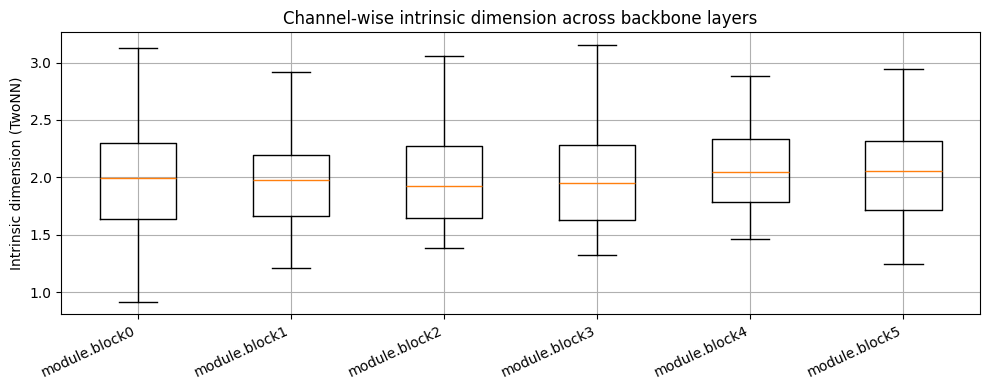

module.block0/conv2/relu: mean=2.001, std=0.513
module.block1/conv2/relu: mean=1.986, std=0.430
module.block2/conv2/relu: mean=1.988, std=0.501
module.block3/conv2/relu: mean=1.958, std=0.426
module.block4/conv2/relu: mean=2.072, std=0.414
module.block5/conv2/relu: mean=2.037, std=0.394


In [7]:
def safe_mean_std(x: torch.Tensor) -> tuple[float, float]:
    x = x[torch.isfinite(x)]
    if x.numel() == 0:
        return float("nan"), float("nan")
    return float(x.mean()), float(x.std(unbiased=False))


selected_backbone = sorted(backbone_dims.keys())
if len(selected_backbone) > 6:
    # Keep a few layers for readability in the default tutorial plot.
    step = max(1, len(selected_backbone) // 6)
    selected_backbone = selected_backbone[::step][:6]

valid_backbone = []
for k in selected_backbone:
    values = backbone_dims[k][torch.isfinite(backbone_dims[k])].numpy()
    if values.size > 0:
        valid_backbone.append((k, values))

if valid_backbone:
    plt.figure(figsize=(10, 4))
    plt.boxplot(
        [vals for _, vals in valid_backbone],
        tick_labels=[k.split("/")[0] for k, _ in valid_backbone],
        showfliers=False,
    )
    plt.ylabel("Intrinsic dimension (TwoNN)")
    plt.title("Channel-wise intrinsic dimension across backbone layers")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No finite per-channel dimensions found for selected backbone layers.")

for k in selected_backbone:
    mu, sigma = safe_mean_std(backbone_dims[k])
    print(f"{k}: mean={mu:.3f}, std={sigma:.3f}")

## Per-Square Board Visualisation

For each activation tensor of shape `(N, C, H, W)`, we fix a board square `(h, w)` and treat `x[:, :, h, w]` as `N` points in `C` dimensions. We then estimate one intrinsic dimension per square and render:

- mean intrinsic dimension per square across selected backbone layers,
- standard deviation per square across selected backbone layers.

In [8]:
def square_intrinsic_dimension(x: torch.Tensor) -> torch.Tensor:
    if x.ndim != 4:
        raise ValueError("Expected activation tensor of shape (N, C, H, W).")
    n, c, h, w = x.shape
    if n < 3:
        raise ValueError("Need at least 3 samples for TwoNN.")

    square_data = x.permute(2, 3, 0, 1).reshape(h * w, n, c)
    dims = []
    for i in range(h * w):
        td_i = TensorDict({"data": square_data[i]}, batch_size=[])
        try:
            d = estimator(td_i)["dimension"].item()
        except Exception:
            d = float("nan")
        dims.append(d)
    return torch.tensor(dims, dtype=torch.float32)


if not selected_backbone:
    print("No backbone layers were captured; skipping board visualisation.")
else:
    usable = []
    usable_names = []
    for k in selected_backbone:
        x = backbone_acts[k]
        if x.shape[2] * x.shape[3] == 64:
            usable.append(square_intrinsic_dimension(x))
            usable_names.append(k)

    if not usable:
        print("No selected layer had H*W == 64, so board mapping is skipped.")
    else:
        dim_stack = torch.stack(usable, dim=0)  # (layers, 64)
        mean_dim = torch.nanmean(dim_stack, dim=0)
        centered = dim_stack - mean_dim.unsqueeze(0)
        std_dim = torch.sqrt(torch.nanmean(centered * centered, dim=0))

        print("Layers used for board maps:")
        for name in usable_names:
            print(f"  - {name}")

        board_template = LczeroBoard()

        def render_square_board(values: torch.Tensor, title: str):
            finite = torch.isfinite(values)
            if not finite.any():
                print(f"{title}: no finite values")
                return

            vals = values.clone()
            fill = torch.nanmean(vals[finite]).item()
            vals[~finite] = fill
            board_flat = vals.reshape(64)
            svg_board, svg_colorbar = board_template.render_heatmap(board_flat.detach(), normalise="none")
            display(HTML(f"<h4>{title}</h4>{svg_board}{svg_colorbar}"))

        render_square_board(mean_dim, "Mean intrinsic dimension per square")
        render_square_board(std_dim, "Std intrinsic dimension per square")

Layers used for board maps:
  - module.block0/conv2/relu
  - module.block1/conv2/relu
  - module.block2/conv2/relu
  - module.block3/conv2/relu
  - module.block4/conv2/relu
  - module.block5/conv2/relu


## Policy vs Value Head-Adjacent Features

We compare channel-wise intrinsic dimensions from the first conv activations after the backbone: `policy/conv1/relu` vs `value/conv/relu`.

Policy key: module.policy/conv1/relu
Value key: module.value/conv/relu


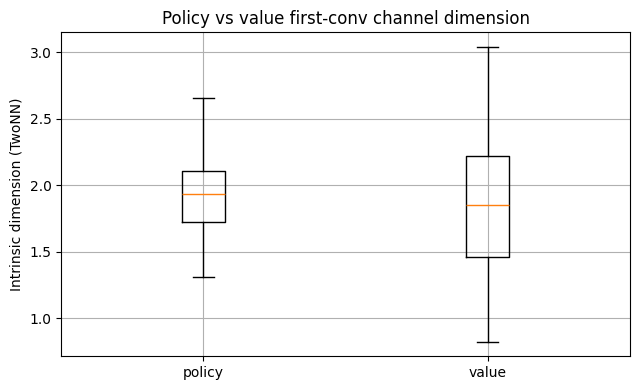

In [9]:
def pick_suffix_key(keys: list[str], suffix: str) -> str | None:
    for k in sorted(keys):
        if k.endswith(suffix):
            return k
    return None


head_keys = [k for k, v in head_acts.items() if v.ndim == 4]
policy_key = pick_suffix_key(head_keys, POLICY_TARGET)
value_key = pick_suffix_key(head_keys, VALUE_TARGET)

head_dims = {}
if policy_key is not None:
    head_dims[policy_key] = channel_intrinsic_dimension(head_acts[policy_key])
if value_key is not None:
    head_dims[value_key] = channel_intrinsic_dimension(head_acts[value_key])

print("Policy key:", policy_key)
print("Value key:", value_key)

if len(head_dims) == 2:
    valid_items = []
    for k, v in head_dims.items():
        values = v[torch.isfinite(v)].numpy()
        if values.size > 0:
            valid_items.append((k, values))

    if len(valid_items) == 2:
        plt.figure(figsize=(6.5, 4))
        plt.boxplot(
            [vals for _, vals in valid_items],
            tick_labels=[k.split(".")[-1].split("/")[0] for k, _ in valid_items],
            showfliers=False,
        )
        plt.ylabel("Intrinsic dimension (TwoNN)")
        plt.title("Policy vs value first-conv channel dimension")
        plt.tight_layout()
        plt.show()
    else:
        print("Policy/value tensors were found but had no finite channel dimensions.")
else:
    print("Could not find both policy and value 4D activations in this model capture.")

## Interpretation and Limitations

- Per-channel intrinsic dimension is sensitive to sample size and to highly redundant activations.
- Per-square board estimates use all `N` samples at each fixed square `(h, w)` with channel features as coordinates.
- Head-module names can vary by model export; this notebook targets policy/value first-conv activations.